In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
import plotly.express as px

In [121]:
df = pd.read_csv("iSUPER_Weather_Underground_merged_2025.csv")
display(df.head())
print(df["Dew/Temp fog?"].value_counts())
df["RH fog?"].value_counts()

,timestamp_utc,rh_sensor,temp_sensor,pm1,pm25,pm10,Temperature_C,Dew_Point_C,Humidity_%,Speed_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,Wind,Dew/Temp fog?,RH fog?
0,2025-08-17 00:00:00+00:00,48.76,27.10,14.38,14.51,14.51,24.06,17.61,67.0,15.12,1016.59,0.0,0.0,SSW,0.0,0.0
1,2025-08-17 00:05:00+00:00,49.02,27.00,13.94,14.24,14.24,23.89,17.56,68.0,15.45,1016.93,0.0,0.0,SSW,0.0,0.0
2,2025-08-17 00:10:00+00:00,49.20,26.90,13.75,14.00,14.00,23.78,17.72,69.0,15.29,1016.93,0.0,0.0,SSW,0.0,0.0
3,2025-08-17 00:15:00+00:00,49.40,26.82,13.68,13.95,16.26,23.83,17.22,67.0,18.34,1016.93,0.0,0.0,SSW,0.0,0.0
4,2025-08-17 00:20:00+00:00,49.50,26.76,12.60,12.73,12.73,24.06,17.33,66.0,14.32,1016.59,0.0,0.0,SSW,0.0,0.0


Dew/Temp fog?
0.0    15645
1.0     6272
Name: count, dtype: int64


RH fog?
0.0    20147
1.0     1792
Name: count, dtype: int64

In [122]:
df["fog_label"] = ((df["Dew/Temp fog?"] > 0) | (df["RH fog?"] > 0)).astype(int)
print(df["fog_label"].value_counts())
df.sample(5)

fog_label
0    19338
1     6294
Name: count, dtype: int64


,timestamp_utc,rh_sensor,temp_sensor,pm1,pm25,pm10,Temperature_C,Dew_Point_C,Humidity_%,Speed_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,Wind,Dew/Temp fog?,RH fog?,fog_label
3216,2025-08-28 04:00:00+00:00,54.74,18.50,2.45,2.49,2.49,17.56,10.94,65.0,1.77,1017.95,0.00,0.00,East,0.0,0.0,0
9348,2025-09-18 11:00:00+00:00,85.64,18.60,2.23,2.23,2.23,16.78,16.61,99.0,1.61,1014.90,0.00,3.56,East,1.0,1.0,1
6291,2025-09-07 20:15:00+00:00,82.72,18.00,3.74,3.96,3.96,16.17,15.06,94.0,4.51,1015.92,1.27,24.38,NE,1.0,0.0,1
1932,2025-08-23 17:00:00+00:00,27.90,34.08,8.69,8.88,8.88,28.44,15.56,45.0,10.62,1016.93,0.00,0.00,WSW,0.0,0.0,0
7418,2025-09-11 18:10:00+00:00,24.00,35.10,5.11,5.15,5.15,23.17,12.67,52.0,4.51,1017.95,0.00,0.00,SE,0.0,0.0,0


In [123]:
feature_cols_all = [
    "rh_sensor",
    "temp_sensor",
    "pm1",
    "pm25",
    "pm10",
    "Temperature_C",
    "Dew_Point_C",
    "Humidity_%",
    "Speed_kmh",
    "Pressure_hPa",
    "Precip_Rate_mm",
    "Precip_Accum_mm",
]

X_raw_all = df[feature_cols_all].dropna()
y = df.loc[X_raw_all.index, "fog_label"]
print(X_raw_all.shape, y.shape)

scaler_all = MinMaxScaler()
X_all = scaler_all.fit_transform(X_raw_all)

(21835, 12) (21835,)


Cluster 0 mean fog_label: 0.477657465304255
Cluster 1 mean fog_label: 0.00045866299736268775
Chosen cluster for fog is cluster 0


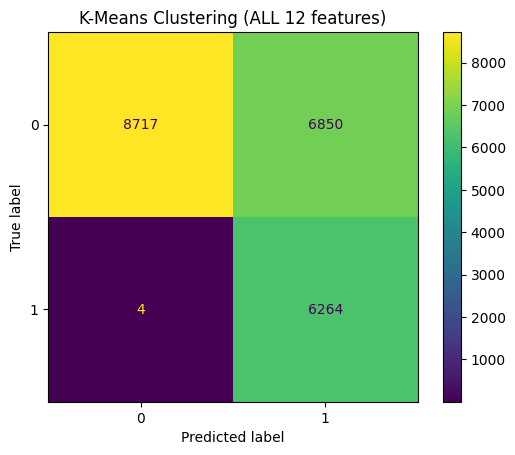


Hard Clustering Performance (ALL features):
              precision    recall  f1-score   support

           0      1.000     0.560     0.718     15567
           1      0.478     0.999     0.646      6268

    accuracy                          0.686     21835
   macro avg      0.739     0.780     0.682     21835
weighted avg      0.850     0.686     0.697     21835



In [124]:
kmeans_all = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_all.fit(X_all)
clusters_all = kmeans_all.labels_

np.unique(clusters_all, return_counts=True)

cluster0_mean = y[clusters_all == 0].mean()
cluster1_mean = y[clusters_all == 1].mean()
print("Cluster 0 mean fog_label:", cluster0_mean)
print("Cluster 1 mean fog_label:", cluster1_mean)

fog_cluster_all = 0 if cluster0_mean > cluster1_mean else 1
print("Chosen cluster for fog is cluster", fog_cluster_all)

# Hard clustering predictions
y_pred_hard = (clusters_all == fog_cluster_all).astype(int)

# Confusion matrix for hard clustering
cm_hard = confusion_matrix(y, y_pred_hard)
disp_hard = ConfusionMatrixDisplay(confusion_matrix=cm_hard, display_labels=[0, 1])
disp_hard.plot()
plt.title(f"K-Means Clustering (12 features)")
plt.show()

print("\nHard Clustering Performance (12 features):")
print(classification_report(y, y_pred_hard, digits=3))


Feature Importance Ranking:
        feature  importance
     Humidity_%    0.511733
      rh_sensor    0.336489
    Dew_Point_C    0.036823
Precip_Accum_mm    0.027691
    temp_sensor    0.026178
  Temperature_C    0.018414
           pm25    0.010828
 Precip_Rate_mm    0.009165
   Pressure_hPa    0.008713
            pm1    0.005270
           pm10    0.004615
      Speed_kmh    0.004081

Using top 5 features for optimization: ['Humidity_%', 'rh_sensor', 'Dew_Point_C', 'Precip_Accum_mm', 'temp_sensor']


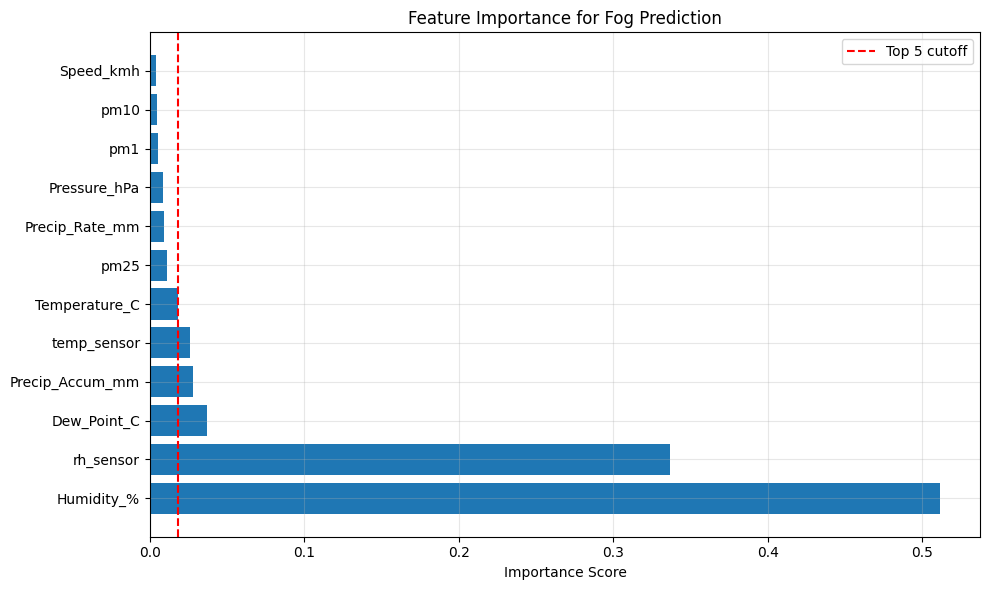


Selected features dataset shape: (21835, 5)


In [125]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_all, y)

feature_importance = pd.DataFrame({
    'feature': feature_cols_all,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Select top n features
top_n = 5
top_features = feature_importance.head(top_n)['feature'].tolist()
print(f"\nUsing top {top_n} features for optimization: {top_features}")

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['feature'], feature_importance['importance'])
ax.axvline(x=feature_importance['importance'].iloc[top_n], 
           color='red', linestyle='--', label=f'Top {top_n} cutoff')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance for Fog Prediction')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Recreate dataset with only top features
X_raw_selected = df[top_features].dropna()
y_selected = df.loc[X_raw_selected.index, "fog_label"]
print(f"\nSelected features dataset shape: {X_raw_selected.shape}")

# Rescale with selected features
scaler_selected = MinMaxScaler()
X_selected = scaler_selected.fit_transform(X_raw_selected)

In [126]:
X_raw_selected = df[top_features].dropna()
y = df.loc[X_raw_selected.index, "fog_label"]
print(f"New dataset shape: {X_raw_selected.shape}")

scaler_selected = MinMaxScaler()
X_selected = scaler_selected.fit_transform(X_raw_selected)

feature_cols = top_features
X_raw = X_raw_selected
X = X_selected

New dataset shape: (21835, 5)


In [127]:
kmeans_selected = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_selected.fit(X_selected)
clusters_selected = kmeans_selected.labels_

cluster0_mean_sel = y_selected[clusters_selected == 0].mean()
cluster1_mean_sel = y_selected[clusters_selected == 1].mean()
print("Cluster 0 mean fog_label:", cluster0_mean_sel)
print("Cluster 1 mean fog_label:", cluster1_mean_sel)

fog_cluster_selected = 0 if cluster0_mean_sel > cluster1_mean_sel else 1
print("Chosen cluster for fog is cluster", fog_cluster_selected)

Cluster 0 mean fog_label: 0.53431080044327
Cluster 1 mean fog_label: 0.0
Chosen cluster for fog is cluster 0


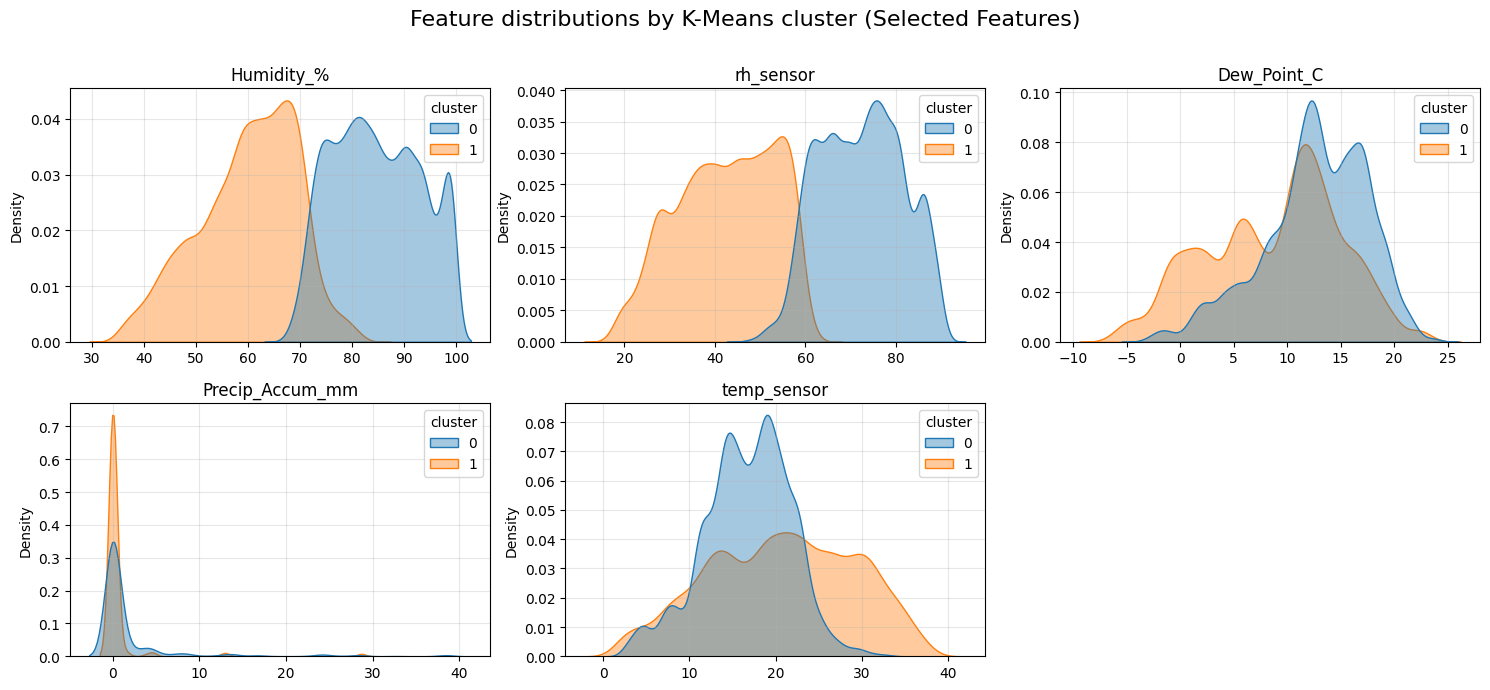

In [128]:
df_feat_vis = X_raw_selected[top_features].copy()
df_feat_vis["cluster"] = clusters_selected

n_features = len(top_features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    sns.kdeplot(
        data=df_feat_vis,
        x=feat,
        hue="cluster",
        common_norm=False,
        fill=True,
        alpha=0.4,
        ax=ax,
    )
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature distributions by K-Means cluster (Selected Features)", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

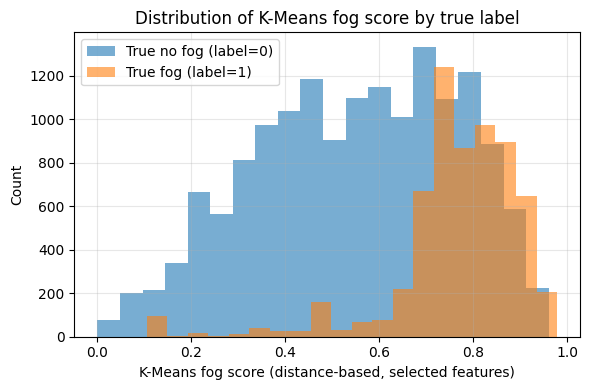

In [129]:
distances = kmeans_selected.transform(X_selected)
fog_distance = distances[:, fog_cluster_selected]
max_dist = fog_distance.max()
fog_proba = 1 - (fog_distance / max_dist)

fog_proba_series = pd.Series(fog_proba, index=X_raw_selected.index)
label_series = y_selected

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(
    fog_proba_series[label_series == 0],
    bins=20,
    alpha=0.6,
    label="True no fog (label=0)"
)
ax.hist(
    fog_proba_series[label_series == 1],
    bins=20,
    alpha=0.6,
    label="True fog (label=1)"
)
ax.set_xlabel("K-Means fog score (distance-based, selected features)")
ax.set_ylabel("Count")
ax.set_title("Distribution of K-Means fog score by true label")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [130]:
thresholds = np.linspace(0.3, 0.7, 20)
best_f1 = 0
best_threshold = 0.5
results = []

for thresh in thresholds:
    y_pred_thresh = (fog_proba_series > thresh).astype(int)
    f1 = f1_score(y_selected, y_pred_thresh)
    precision = precision_score(y_selected, y_pred_thresh)
    recall = recall_score(y_selected, y_pred_thresh)
    
    results.append({
        'threshold': thresh,
        'f1': f1,
        'precision': precision,
        'recall': recall
    })
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

results_df = pd.DataFrame(results)

print(f"\nBest threshold: {best_threshold:.3f}")
print(f"Best F1-score: {best_f1:.3f}")


Best threshold: 0.679
Best F1-score: 0.646


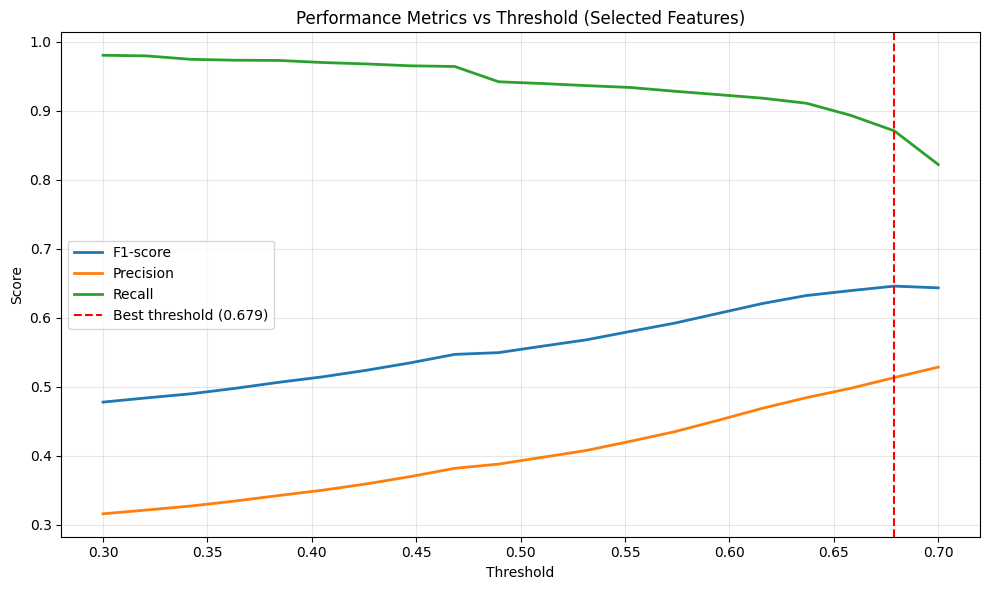

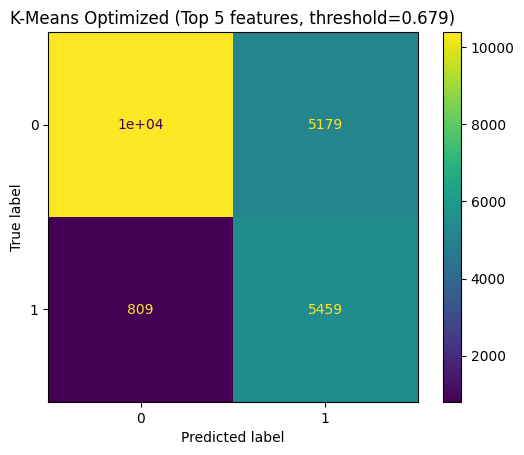


Optimized Performance (Selected features, threshold=0.679):
              precision    recall  f1-score   support

           0      0.928     0.667     0.776     15567
           1      0.513     0.871     0.646      6268

    accuracy                          0.726     21835
   macro avg      0.720     0.769     0.711     21835
weighted avg      0.809     0.726     0.739     21835



In [131]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['threshold'], results_df['f1'], label='F1-score', linewidth=2)
ax.plot(results_df['threshold'], results_df['precision'], label='Precision', linewidth=2)
ax.plot(results_df['threshold'], results_df['recall'], label='Recall', linewidth=2)
ax.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best threshold ({best_threshold:.3f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs Threshold (Selected Features)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


y_pred_optimized = (fog_proba_series > best_threshold).astype(int)

cm_opt = confusion_matrix(y_selected, y_pred_optimized)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=[0, 1])
disp_opt.plot()
plt.title(f"K-Means Optimized (Top {top_n} features, threshold={best_threshold:.3f})")
plt.show()

print(f"\nOptimized Performance (Selected features, threshold={best_threshold:.3f}):")
print(classification_report(y_selected, y_pred_optimized, digits=3))

Visualizing with top 2 features: Humidity_% and rh_sensor


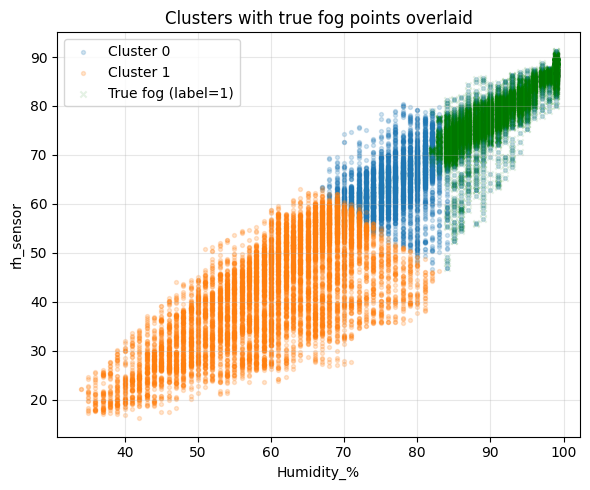

In [132]:
f1 = top_features[0]
f2 = top_features[1]
print(f"Visualizing with top 2 features: {f1} and {f2}")

x1 = X_raw_selected[f1]
x2 = X_raw_selected[f2]

fig, ax = plt.subplots(figsize=(6, 5))
for k in np.unique(clusters_selected):
    mask = clusters_selected == k
    ax.scatter(
        x1[mask],
        x2[mask],
        s=8,
        alpha=0.2,
        label=f"Cluster {k}"
    )

fog_mask = (y_selected == 1)
ax.scatter(
    x1[fog_mask],
    x2[fog_mask],
    s=20,
    marker="x",
    color="green",
    label="True fog (label=1)",
    alpha=0.1
)

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_title("Clusters with true fog points overlaid")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

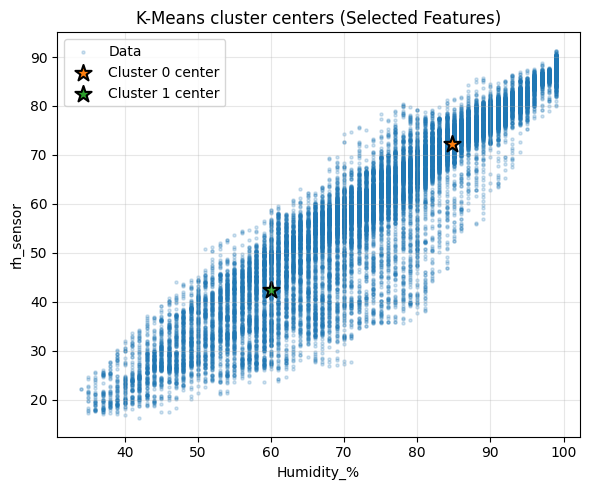

In [133]:
centers_scaled = kmeans_selected.cluster_centers_
centers_orig = scaler_selected.inverse_transform(centers_scaled)

f1_idx = top_features.index(f1)
f2_idx = top_features.index(f2)
centers_orig_f1 = centers_orig[:, f1_idx]
centers_orig_f2 = centers_orig[:, f2_idx]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_raw_selected[f1], X_raw_selected[f2], s=5, alpha=0.2, label="Data")

for k in range(centers_orig.shape[0]):
    ax.scatter(
        centers_orig_f1[k],
        centers_orig_f2[k],
        s=150,
        marker="*",
        edgecolors='black',
        linewidths=1.5,
        label=f"Cluster {k} center"
    )

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_title("K-Means cluster centers (Selected Features)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

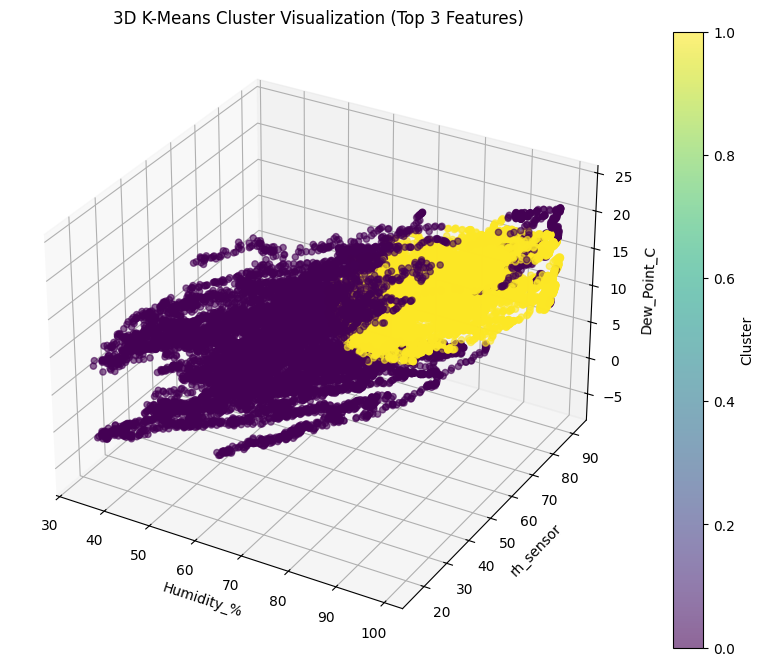

In [134]:
pm_features = ['pm1', 'pm25', 'pm10']
if all(feat in top_features for feat in pm_features):
    df_pm3d = X_raw_selected[pm_features].copy()
    df_pm3d["cluster"] = y_pred_optimized
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(df_pm3d["pm1"], df_pm3d["pm25"], df_pm3d["pm10"],
                         c=df_pm3d["cluster"], cmap='viridis', alpha=0.6)
    ax.set_xlabel('PM1')
    ax.set_ylabel('PM2.5')
    ax.set_zlabel('PM10')
    ax.set_title('3D K-Means Cluster Visualization (Optimized, Selected Features)')
    plt.colorbar(scatter, label='Cluster')
    plt.show()
else:
    # Use top 3 features instead
    if len(top_features) >= 3:
        df_3d = X_raw_selected[top_features[:3]].copy()
        df_3d["cluster"] = y_pred_optimized
        
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(df_3d.iloc[:, 0], df_3d.iloc[:, 1], df_3d.iloc[:, 2],
                             c=df_3d["cluster"], cmap='viridis', alpha=0.6)
        ax.set_xlabel(top_features[0])
        ax.set_ylabel(top_features[1])
        ax.set_zlabel(top_features[2])
        ax.set_title('3D K-Means Cluster Visualization (Top 3 Features)')
        plt.colorbar(scatter, label='Cluster')
        plt.show()
